# AI for Synovium – Iteration 7

```
Ground truth labels were revised and additional annotations were added.

 - Training tiles with annotation coverage ≤10% were excluded
 - Number of classes: 12 + background = 13 classes  
"Immune cells", "plasma", "Fibro(loose)", "Fibro(dense, regular)",
"Fibro(dense, irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"


Mixed precision was used.
```

In [ ]:
import os
os.environ["CONDA_PREFIX"]

In [ ]:
from Custom_semantic_keras.losses import *
from Custom_semantic_keras.models import *
from Custom_semantic_keras.prediction_tools import *
from Custom_semantic_keras.preparing_tools import *
from Custom_semantic_keras.training_tools import *
from Custom_semantic_keras.tiling_tools import *

In [ ]:
# Pad images
pad_image(image_paths=None,
         image_dir="data/Train/Images",
         extension="jpg",
         tileSize=512)

In [ ]:
## Prepare image paths
train_image_paths, train_mask_paths, val_image_paths, val_mask_paths = PrepareTrainValPath(
    images_dir="data/Train/Images",
    masks_dir="data/Train/Labels",
    train_ratio=0.8,
    image_extension="jpg",
    images_path=None,
    masks_path=None,
    seed=1)

len(train_image_paths), len(train_mask_paths), len(val_image_paths), len(val_mask_paths)

(2152, 2152, 538, 538)

In [ ]:
## Create dataset
train_dataset = GenerateDataset(
    image_paths=train_image_paths,
    mask_paths=train_mask_paths,
    batch_size=20,
    image_size=512,
    center_zero=True,
    data_augment=True)

val_dataset = GenerateDataset(
    image_paths=val_image_paths,
    mask_paths=val_mask_paths,
    batch_size=10, 
    image_size=512,
    center_zero=True,
    data_augment=False)

In [ ]:
model = CustomModel_EffiNetV2(
    image_size=512,
    num_classes=14,
    mixed_float16=True)
model.dtype_policy

## Train for 200 epochs without early stopping

In [ ]:
top5_acc = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, decay=0.0001),
    loss=Dice_SCCE_loss,
    metrics=["accuracy",
             top5_acc,
             Dice,
             IoU,
             UpdatedMeanIoU(num_classes=14)]
    )

# EarlyStop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)

history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    # callbacks=[EarlyStop],
                    epochs=200)

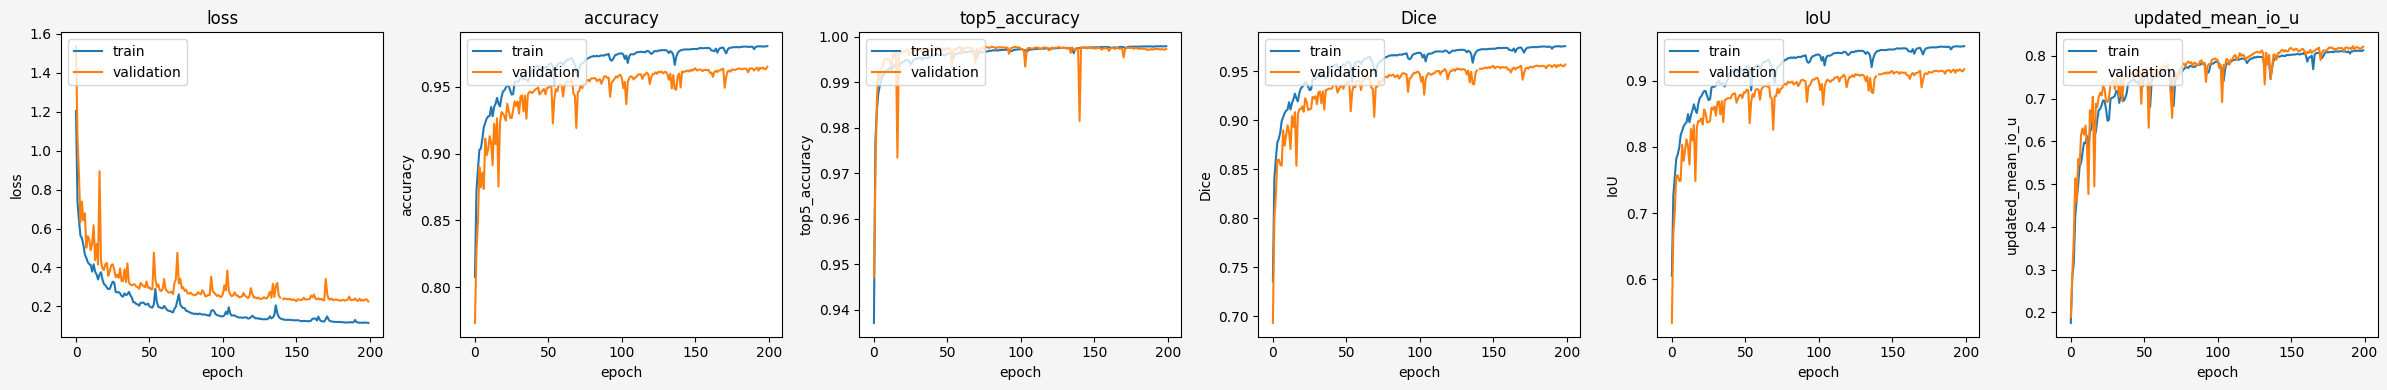

In [ ]:
PlotHistory(history=history, figsize=4)

Training images


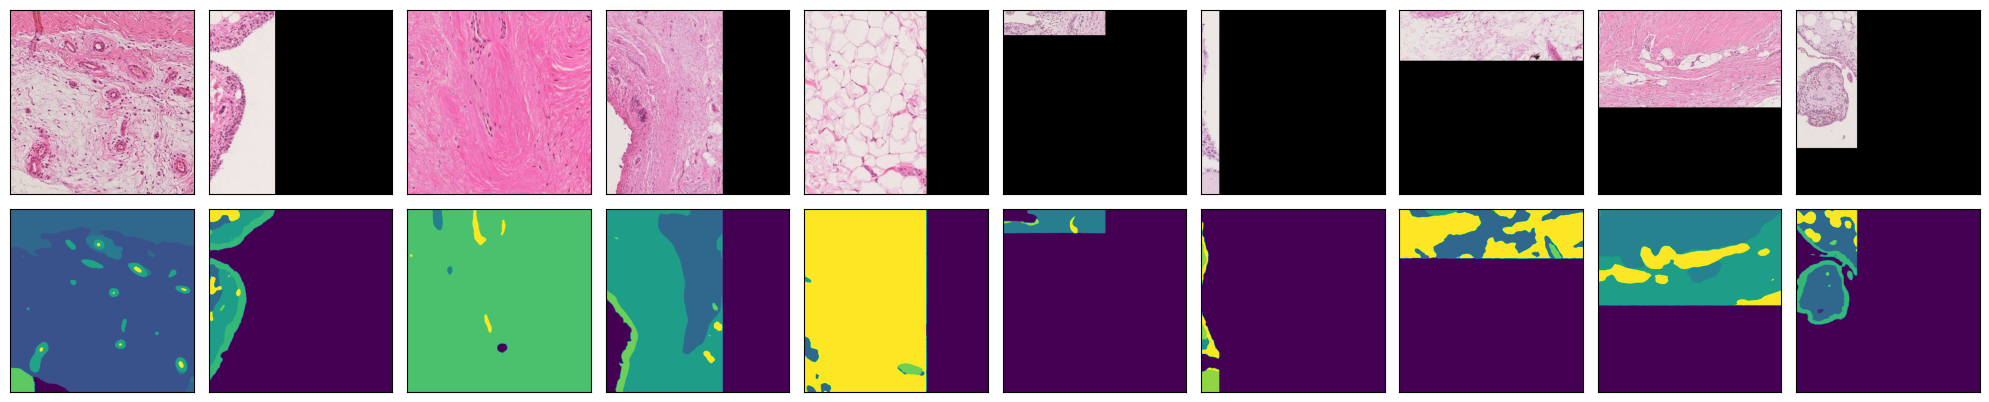

Validation images


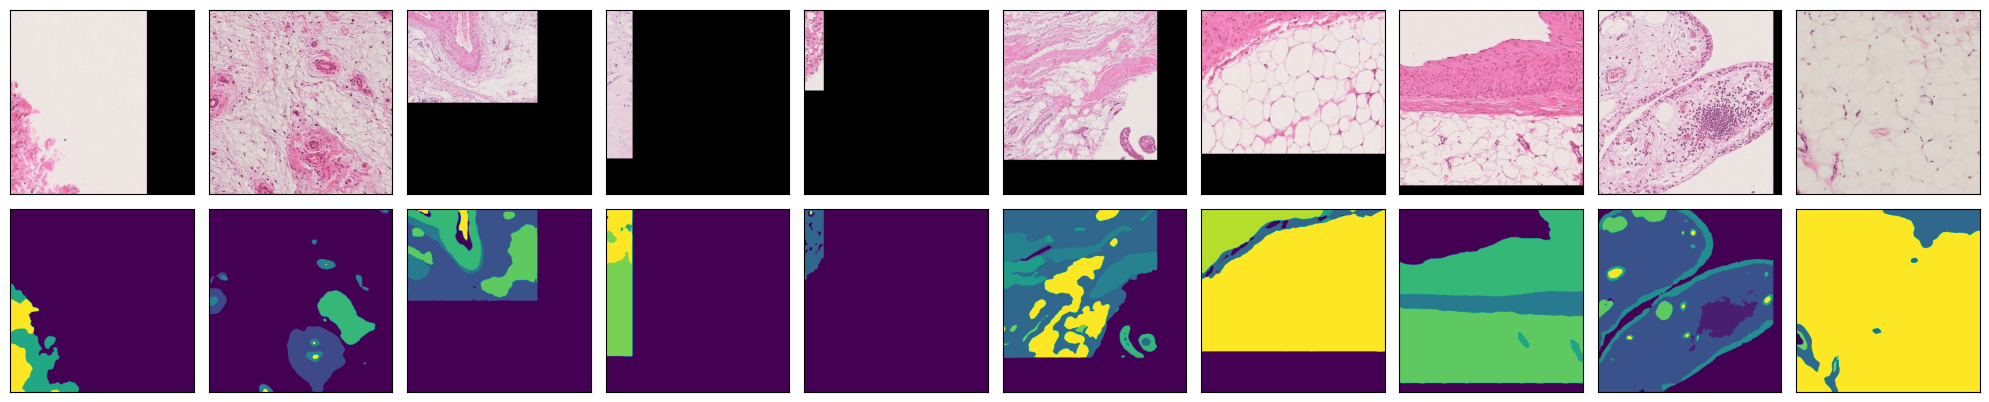

In [ ]:
CheckPrediction(model=model,
                train_image_paths=train_image_paths,
                val_image_paths=val_image_paths,
                figsize=20)

Training images


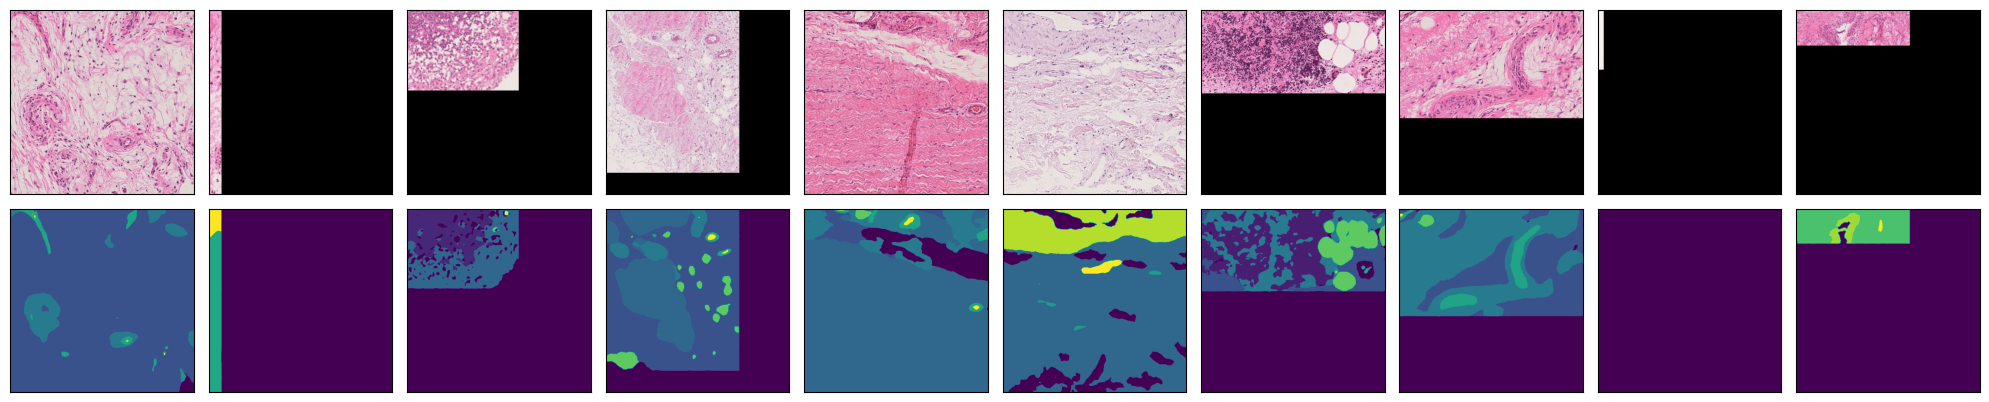

Validation images


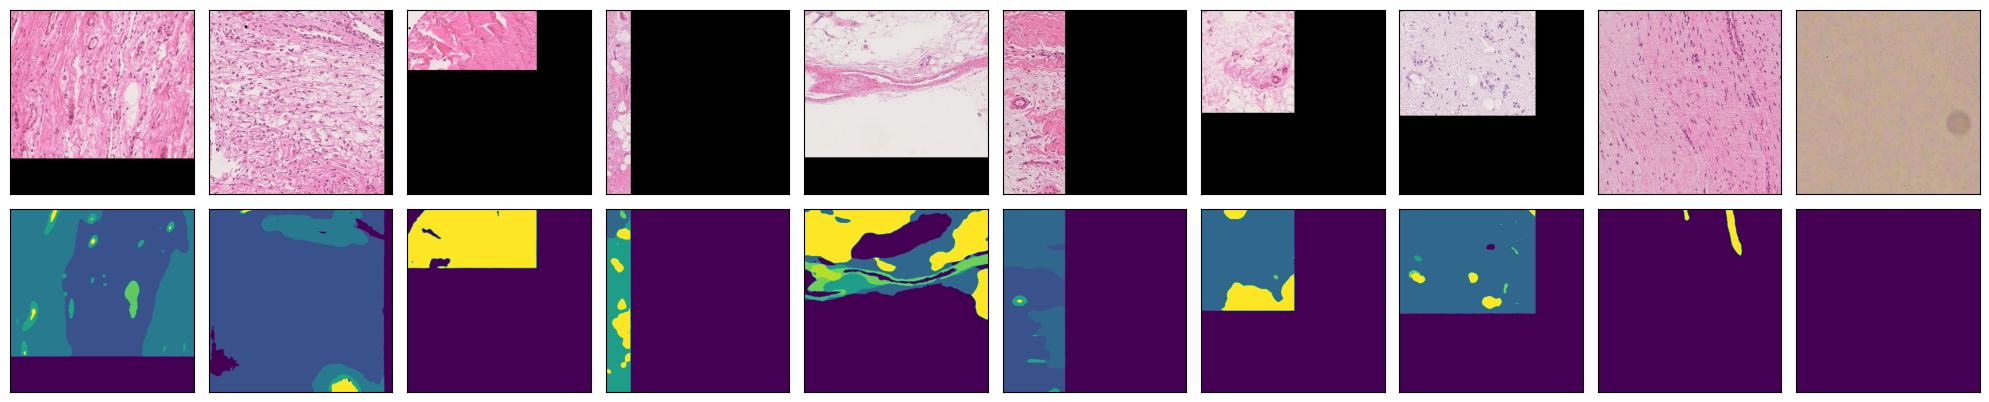

In [ ]:
CheckPrediction(model=model,
                train_image_paths=train_image_paths,
                val_image_paths=val_image_paths,
                figsize=20)

In [ ]:
model.save("model_weights/model7_241111.h5")

### -> Inference is performed within QuPath using the trained model.
Run scripts 01–06 in the qupath/scripts directory sequentially within QuPath.